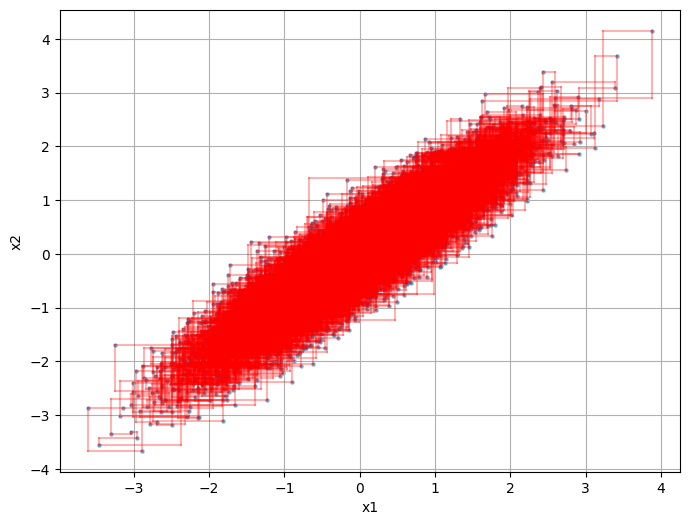

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
r"""
    How to derive the conditional densities?
    The conditional density of X_1 \mid X_2 = x_2 is the ratio of an exponential of
     a quadratic polynomial by an exponential of a quadratic polynomial,
    thus it is also an exponential of a quadratic polynomial.
    We know from there that is must be Gaussian.
    We also know the conditional density is proportional to the joint which is proportional to
        \exp\{- \frac{1}{(1-\rho^2)} (x_1^2 - 2\rho x_1 x_2 + x_2^2)\}.
    Looking at the quadratic polynomial inside the exponential,
    isolating the terms in x_1 and completing the square so to obtain a Gaussian density,
    we end up with a conditional density proportional to
        \exp\{- \frac{1}{(1-\rho^2)} (x_1-\mu_1(x_2))^2\},
    where \mu_1(x_2) = \rho x_2.

    Thus, X_1\mid X_2 is a Gaussian centered at \rho x_2 with variance (1-\rho^2).
    Mutatis mutandis for X_2\mid X_1.
    """
rho = 0.9
def gibbs_sampler(seed, n_samples, burnin):
  np.random.seed(seed)
  my_samples = np.zeros((n_samples+burnin, 2))
  my_samples[0] = np.random.multivariate_normal(np.zeros(2), np.eye(2))

  for n in range(1, n_samples + burnin):
    conditional_std = np.sqrt(1-rho**2)


    previous_x2 = my_samples[n-1, 1]
    conditional_mean_given_x2 = rho * previous_x2
    draw_x1_conditional_on_previous_x2 = np.random.normal(conditional_mean_given_x2, conditional_std)
    my_samples[n, 0] = draw_x1_conditional_on_previous_x2

    previous_x1 = my_samples[n, 0]
    conditional_mean_given_x1 = rho * previous_x1
    draw_x2_conditional_on_previous_x1 = np.random.normal(conditional_mean_given_x1, conditional_std)

    my_samples[n, 1] = draw_x2_conditional_on_previous_x1


  return my_samples[burnin:]

samples = gibbs_sampler(0, 10000, 100)

plt.figure(figsize=(8, 6))
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.5, s=5)
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid()


for i in range(1, len(samples)):
  plt.plot([samples[i-1, 0], samples[i, 0]], [samples[i-1, 1], samples[i-1, 1]], alpha=0.3, color="red")
  plt.plot([samples[i, 0], samples[i, 0]], [samples[i-1, 1], samples[i, 1]], alpha=0.3, color="red")


